### Libraries and Functions

In [1]:
import pandas as pd
import numpy as np
import pickle

from tqdm import tqdm
from sympy import Basic
from joblib import Parallel, delayed
from matplotlib.patches import Patch
from func_timeout import func_timeout, FunctionTimedOut

from symbolic_regression.utils.visualization import plot_results
from symbolic_regression.utils.model_utils import tree_size

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
def get_final_expr(
    dataset_equations: dict[str, list],
    method: str,
    run_idx: int
) -> Basic:
    """
    Extracts the final SymPy expression for a given method and run.

    For the 'RFGPCMI' method, it returns the sum of the final sub-expressions. 
    For all other methods, it returns the single final expression.

    Parameters
    ----------
    dataset_equations : dict[str, list]
        A dictionary containing the equations for a dataset, keyed by method name.
    method : str
        The name of the symbolic regression method (e.g., 'GP', 'RFGPCMI').
    run_idx : int
        The index of the execution run to extract the expression from.

    Returns
    -------
    Basic
        The final SymPy expression.
    """

    if method != "RFGPCMI":
        return dataset_equations [method][run_idx][-1].sympy_format
    
    else:
        return sum(
            sub_expr[-1].sympy_format
            for sub_expr in dataset_equations [method][run_idx]
        ) # type: ignore

def safe_simplify_timeout(
    expr: Basic,
    timeout_seconds: int = 5
):
    """
    Attempts to simplify a SymPy expression within a specified time limit.

    This function uses `func_timeout` to prevent the `simplify` method 
    from running indefinitely. If the simplification takes longer than 
    the given timeout, the original, unsimplified expression is returned.
    Any other exceptions raised during simplification are propagated naturally.

    Parameters
    ----------
    expr : sympy.core.basic.Basic
        The SymPy mathematical expression to be simplified.
    timeout_seconds : int or float, optional
        The maximum number of seconds to allow the simplification process 
        to run. Default is 5.

    Returns
    -------
    sympy.core.basic.Basic
        The simplified SymPy expression if successful and within the time 
        limit; otherwise, the original `expr`.
    """

    try: 
        return func_timeout(timeout_seconds, expr.simplify)
    except FunctionTimedOut:
        return expr

### Data Preprocessing

In [3]:
# Load real dataset results
with open('data_real.pkl', "rb") as f:
    real = pickle.load(f)['kwargs']

results_df, features = real['df'], real['features'],
equations, execution_times = real['equations'], real['execution_times']

# Calculate the number dataframe index runs level
num_runs = results_df.index.get_level_values('run').nunique()

# Reorder MultiIndex columns for consistent plotting
order = {
    'dataset': ['197_cpu_act', '4544_GOM', '505_tecator', 'CCN', 'CCUN'],
    'method':  ['GPPI', 'GPSHAP', 'GPCMI', 'RFGPCMI', 'GP'],
    'metric':  ['training_losses', 'validation_losses', 'test_losses']
}

for level, cols in order.items():
    results_df = results_df.reindex(columns=cols, level=level)

results_df.tail(3)

dataset       197_cpu_act                                                \
method               GPPI                                        GPSHAP   
metric    training_losses validation_losses test_losses training_losses   
run epoch                                                                 
99  90           0.085219          0.084149    0.085306        0.045534   
    95           0.084591          0.085717    0.085306        0.044165   
    100          0.085040          0.084600    0.085306        0.044693   

dataset                                                                    \
method                                            GPCMI                     
metric    validation_losses test_losses training_losses validation_losses   
run epoch                                                                   
99  90             0.043935    0.044745        0.110546          0.109176   
    95             0.043669    0.043691        0.109700          0.111288   
    100            0.042306    0.043691        0.111237          0.107406   

dataset                                ...        CCUN                  \
method                        RFGPCMI  ...      GPSHAP           GPCMI   
metric    test_losses training_losses  ... test_losses training_losses   
run epoch                              ...                               
99  90       0.110328        0.079541  ...    0.133757        0.142017   
    95       0.110328        0.079541  ...    0.146277        0.148848   
    100      0.110328        0.079541  ...    0.141008        0.163460   

dataset                                                                    \
method                                          RFGPCMI                     
metric    validation_losses test_losses training_losses validation_losses   
run epoch                                                                   
99  90             0.174450    0.141383        0.139470          0.129479   
    95             0.169583    0.146690        0.141419          0.129395   
    100            0.121239    0.140984        0.137320          0.126764   

dataset                                                              
method                             GP                                
metric    test_losses training_losses validation_losses test_losses  
run epoch                                                            
99  90       0.133781        0.162251          0.135887    0.137342  
    95       0.134067        0.171804          0.182566    0.162457  
    100      0.132307        0.152875          0.168753    0.137342  

[3 rows x 75 columns]

### Predictive Performance

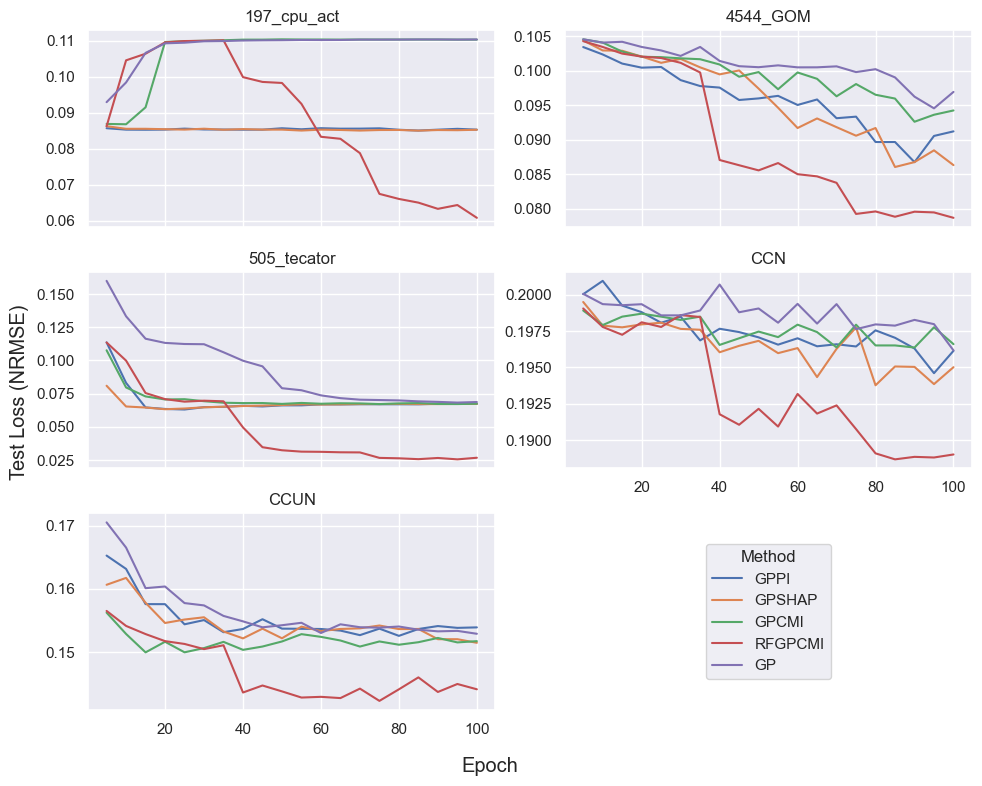

In [4]:
# Plotting test losses for each dataset and method per epoch
fig, axes = plot_results(
    results_df.groupby(level='epoch').median(), 
    nrows=3, 
    ncols=2,
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level="metric",
    value_key="test_losses",
    plotting_function=lambda data, ax: sns.lineplot(data=data, ax=ax, dashes=None)
)

# Set X and Y label for the entire figure
fig.supxlabel("Epoch", x=0.5, y=0.02)
fig.supylabel("Test Loss (NRMSE)", x=0.02, y=0.5)

axes[4].set_xlabel("") # Hide the x-label

# Remove legends from individual subplots
for ax in axes[:5]: ax.get_legend().remove()

# Take the legend handles and labels from the first subplot
handles, labels = axes[0].get_legend_handles_labels()

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center',
    title="Method"
)
plt.show()

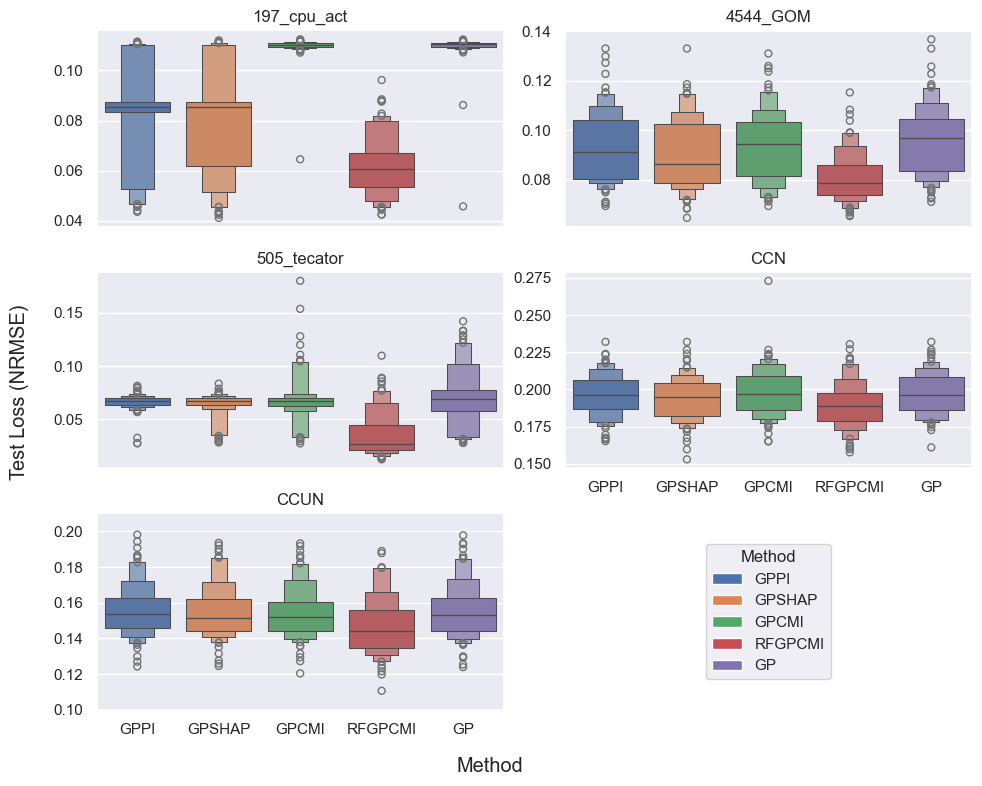

In [5]:
# Plotting test losses for each dataset and method at the last epoch
fig, axes = plot_results(
    results_df.groupby(level='run').last(), 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level="metric", 
    value_key="test_losses",
    plotting_function=lambda data, ax: sns.boxenplot(data=data, ax=ax)
)

# Set X and Y label for the entire figure
fig.supxlabel("Method", x=0.5, y=0.02)
fig.supylabel("Test Loss (NRMSE)", x=0.02, y=0.5)

axes[4].set_ylim(0.1, 0.21) # Set y-axis limits to zoom in on the boxenplots

# Create a custom legend with the same colors as the boxenplots
colors = sns.color_palette(n_colors=len(order['method']))
handles = [Patch(facecolor=c) for c in colors]
labels = order['method'].copy()

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Method"
)
plt.show()

In [6]:
# Calculate median test losses for each method and dataset at the last epoch
median_loss = results_df.groupby(level='run').last().median()
gp_median_loss = median_loss[:, "GP", :]

# Extract the list of methods excluding "GP" for comparison
methods = results_df.columns.levels[1].to_list()
methods.remove("GP")

# Extract the median losses for the competitor methods
competitor_median_loss = median_loss.loc[:, methods, :]

# Calculate relative improvement of GP over competitors for each dataset and metric
relative_improvement = (gp_median_loss - competitor_median_loss) * 100 / gp_median_loss
relative_improvement_df = relative_improvement.to_frame().T

# Reorder the relative improvement DataFrame to match the desired column order for plotting
relative_improvement_df = relative_improvement_df.swaplevel('metric', 'method', axis=1)
relative_improvement_df = relative_improvement_df.reindex(columns=order['dataset'], level='dataset')
relative_improvement_df = relative_improvement_df.reindex(columns=methods, level='method')
relative_improvement_df = relative_improvement_df.reindex(columns=order['metric'], level='metric')
relative_improvement_df

dataset     197_cpu_act                                                \
method             GPPI                                        GPSHAP   
metric  training_losses validation_losses test_losses training_losses   
0             22.837529         23.079297   22.705216       23.188535   

dataset                                                                  \
method                                          GPCMI                     
metric  validation_losses test_losses training_losses validation_losses   
0               23.056897   22.735458        0.083982         -0.125337   

dataset                              ...        CCUN                  \
method                      RFGPCMI  ...        GPPI          GPSHAP   
metric  test_losses training_losses  ... test_losses training_losses   
0          0.037347       45.372097  ...   -0.662397       -1.526991   

dataset                                                                  \
method                                          GPCMI                     
metric  validation_losses test_losses training_losses validation_losses   
0                2.071164    0.935366        1.095375          1.998868   

dataset                                                            
method                      RFGPCMI                                
metric  test_losses training_losses validation_losses test_losses  
0           0.76335        9.284465         12.132357    5.748787  

[1 rows x 60 columns]

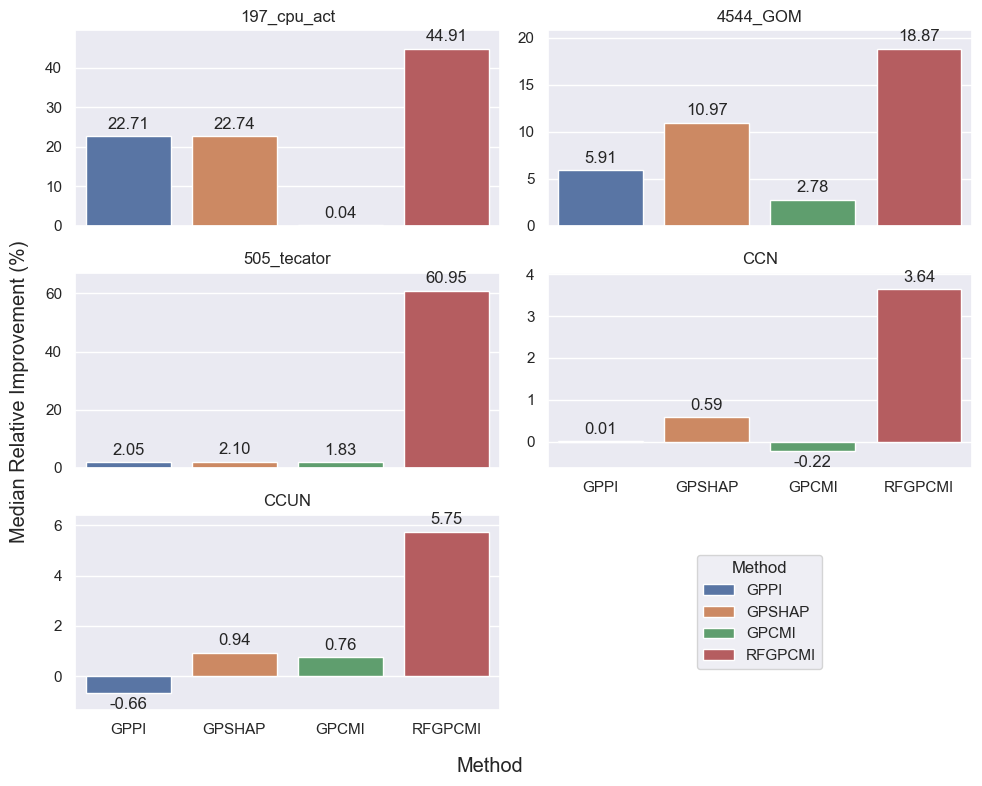

In [7]:
# Plotting relative performance of each method compared to GP for each dataset
fig, axes = plot_results(
    relative_improvement_df, 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level="metric", 
    value_key="test_losses",
    plotting_function=lambda data, ax: sns.barplot(data=data, ax=ax),
)

# Set X and Y label for the entire figure
fig.supxlabel("Method", x=0.5, y=0.02)
fig.supylabel("Median Relative Improvement (%)", x=0.02, y=0.5)

axes[3].tick_params(axis='x', labelbottom=True) # Restore x-tick labels

# Add value labels on top of each bar and adjust y-axis limits for better visibility
for ax in axes[:5]:
    base_padding = 3
    margin_ratio = 0.05

    bottom, top = ax.get_ylim()
    y_padding = margin_ratio * (top - bottom)

    new_top = top + (y_padding if top else 0)
    new_bottom = bottom - (y_padding if bottom else 0)
    ax.set_ylim(new_bottom, new_top)

    for container in ax.containers:
        v = container.datavalues[0]
        adjusted_padding = base_padding if (v != 0) or (top > 0) else -(11 + base_padding)
        ax.bar_label(container, fmt='%.2f', padding=adjusted_padding)

# Take the legend handles and labels from the fifth subplot
handles = axes[4].containers
labels = [text.get_text() for text in axes[4].get_xticklabels()]

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Method"
)
plt.show()

### Model Complexity

In [8]:
# Calculate tree sizes for each run, method, and dataset in parallel using joblib
tree_sizes = {}
for ds in order['dataset']:
    tree_sizes[ds] = {}

    for m in order['method']:
        tree_sizes[ds][m] = Parallel(n_jobs=1)(
            delayed(tree_size)(
                safe_simplify_timeout(get_final_expr(equations[ds], m, run), 10)
            ) for run in tqdm(range(num_runs), desc=f"Calculating tree sizes for {ds} - {m}")  
        )

Calculating tree sizes for CCUN - GP: 100%|██████████| 100/100 [00:00<00:00, 195.01it/s]


In [9]:
# Create a DataFrame to store tree sizes with MultiIndex columns for dataset and method
tree_sizes_column_order = pd.MultiIndex.from_product([order['dataset'], order['method']], names=['dataset', 'method'])

tree_sizes_df = pd.concat(
    {ds: pd.DataFrame(tree_sizes[ds]) for ds in order['dataset']},
    axis=1,
).reindex(columns=tree_sizes_column_order)
tree_sizes_df.index.name = "run"
tree_sizes_df.tail(3)

dataset 197_cpu_act                         4544_GOM                           \
method         GPPI GPSHAP GPCMI RFGPCMI GP     GPPI GPSHAP GPCMI RFGPCMI  GP   
run                                                                             
97                5      5     5      23  5        6      6     2      30  10   
98                5     15     5      36  5        2      6     2      13   2   
99                5     10     5      13  5        6      6     2       7   6   

dataset  ...  CCN                         CCUN                          
method   ... GPPI GPSHAP GPCMI RFGPCMI GP GPPI GPSHAP GPCMI RFGPCMI GP  
run      ...                                                            
97       ...    2      2     2      13  2    3      3     6      34  3  
98       ...    2      2     5      18  2    3      6     5      17  3  
99       ...    2      5     6      30  2    5      3     3      11  5  

[3 rows x 25 columns]

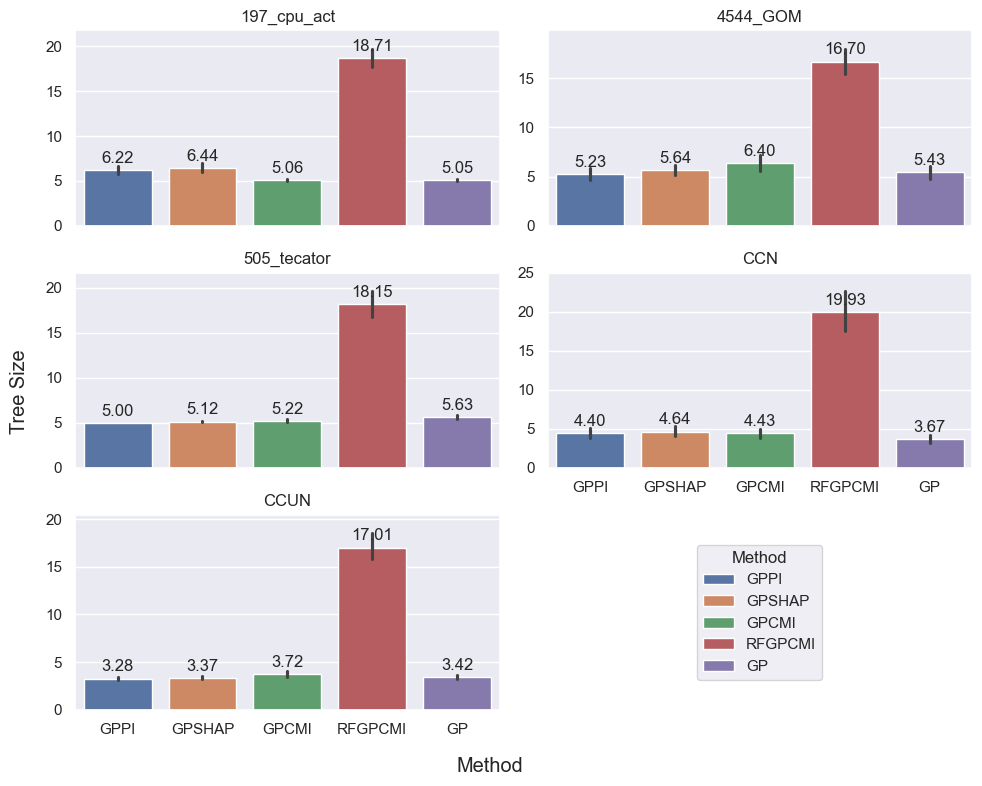

In [10]:
# Plotting tree sizes for each dataset and method at the last epoch
fig, axes = plot_results(
    tree_sizes_df, 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level=None, 
    value_key=None,
    plotting_function=lambda data, ax: sns.barplot(data=data, ax=ax),
)

# Set X and Y label for the entire figure
fig.supxlabel("Method", x=0.5, y=0.02)
fig.supylabel("Tree Size", x=0.02, y=0.5)

axes[3].tick_params(axis='x', labelbottom=True) # Restore x-tick labels

# Add value labels on top of each bar and adjust y-axis limits for better visibility
for ax in axes[:5]:
    base_padding = 3
    margin_ratio = 0.05

    bottom, top = ax.get_ylim()
    y_padding = margin_ratio * (top - bottom)

    new_top = top + (y_padding if top else 0)
    new_bottom = bottom - (y_padding if bottom else 0)
    ax.set_ylim(new_bottom, new_top)

    for container in ax.containers:
        v = container.datavalues[0]
        adjusted_padding = base_padding if (v != 0) or (top > 0) else -(11 + base_padding)
        ax.bar_label(container, fmt='%.2f', padding=adjusted_padding)

# Take the legend handles and labels from the fifth subplot
handles = axes[4].containers
labels = [text.get_text() for text in axes[4].get_xticklabels()]

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Method"
    )
plt.show()

### Feature Selection Analysis

In [11]:
# Total initial number of features for each real dataset
total_features_per_dataset = {ds: len(features[ds]['GP'][0]) for ds in features}    

# Extract the list of methods excluding "GP" for comparison
methods = results_df.columns.levels[1].to_list()
methods.remove("GP")

In [12]:
# Calculate feature retention rate (percentage) for each method and dataset
retention_rates = {}

for dataset_name in order['dataset']:
    retention_rates[dataset_name] = {}
    total_features = total_features_per_dataset[dataset_name]

    for method_name in methods:
        retention_rates[dataset_name][method_name] = np.empty(num_runs)
        features_selected = features[dataset_name][method_name]

        for run in range(num_runs): 
            if method_name == "RFGPCMI":
                selected_features = set()

                for feature_list in features_selected[run]:
                    selected_features.update(feature_list)
                    
            else:
                selected_features = set(features_selected[run])

            # Percentage of original features retained
            retention_rates[dataset_name][method_name][run] = (len(selected_features) / total_features) * 100

In [13]:
# Create a DataFrame to store retention rates with MultiIndex columns for dataset and method
retention_column_order = pd.MultiIndex.from_product(
    [order['dataset'], methods], names=['dataset', 'method']
)

retention_rate_df = pd.concat(
    {
        ds: pd.DataFrame(retention_rates[ds])
        for ds in order['dataset']
    },
    axis=1,
).reindex(columns=retention_column_order)
retention_rate_df.index.name = "run"
retention_rate_df.tail(3)

dataset 197_cpu_act                                   4544_GOM            \
method         GPPI     GPSHAP      GPCMI    RFGPCMI      GPPI    GPSHAP   
run                                                                        
97        14.285714  19.047619  71.428571  80.952381  8.547009  5.982906   
98         4.761905  19.047619  66.666667  71.428571  7.692308  5.982906   
99         4.761905  19.047619  66.666667  76.190476  8.547009  5.982906   

dataset                       505_tecator                                  \
method       GPCMI    RFGPCMI        GPPI    GPSHAP      GPCMI    RFGPCMI   
run                                                                         
97        6.837607  11.965812    9.677419  5.645161  91.935484  94.354839   
98        9.401709  18.803419   12.096774  5.645161  92.741935  94.354839   
99       12.820513  12.820513    8.064516  5.645161   3.225806   6.451613   

dataset       CCN                                     CCUN            \
method       GPPI    GPSHAP     GPCMI    RFGPCMI      GPPI    GPSHAP   
run                                                                    
97       9.016393  5.737705  7.377049  15.573770  2.419355  5.645161   
98       5.737705  5.737705  8.196721   9.016393  3.225806  5.645161   
99       9.836066  5.737705  9.016393  15.573770  6.451613  5.645161   

dataset                       
method      GPCMI    RFGPCMI  
run                           
97       5.645161   9.677419  
98       1.612903  11.290323  
99       4.838710   6.451613

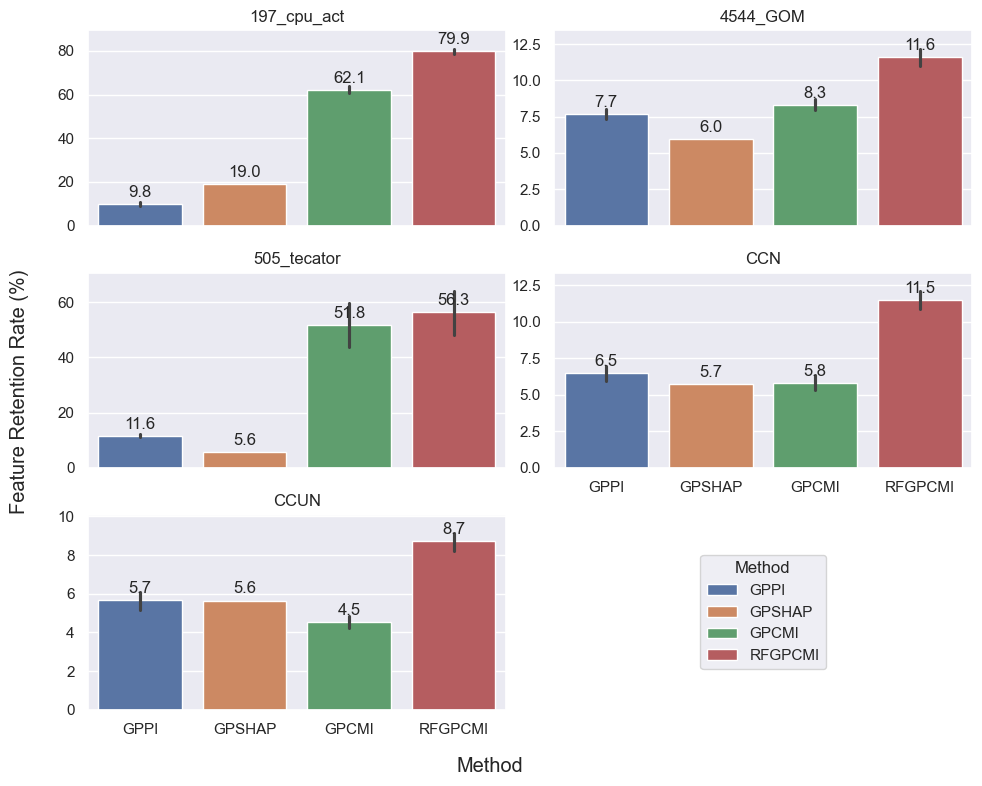

In [14]:
# Plotting feature retention rates for each dataset and method
fig, axes = plot_results(
    retention_rate_df, 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level=None, 
    value_key=None,
    plotting_function=lambda data, ax: sns.barplot(data=data, ax=ax),
)

# Set X and Y label for the entire figure
fig.supxlabel("Method", x=0.5, y=0.02)
fig.supylabel("Feature Retention Rate (%)", x=0.02, y=0.5)

axes[3].tick_params(axis='x', labelbottom=True) # Restore x-tick labels

# Add value labels on top of each bar and adjust y-axis limits for better visibility
for ax in axes[:5]:
    base_padding = 3
    margin_ratio = 0.05

    # ax.axhline(y=100, color='black', linestyle='--', linewidth=1)

    bottom, top = ax.get_ylim()
    y_padding = margin_ratio * (top - bottom)

    new_top = top + (y_padding if top else 0)
    new_bottom = bottom - (y_padding if bottom else 0)
    ax.set_ylim(new_bottom, new_top)

    for container in ax.containers:
        v = container.datavalues[0]
        adjusted_padding = base_padding if (v != 0) or (top > 0) else -(11 + base_padding)
        ax.bar_label(container, fmt='%.1f', padding=adjusted_padding)

# Take the legend handles and labels from the fifth subplot
handles = axes[4].containers
labels = [text.get_text() for text in axes[4].get_xticklabels()]

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Method"
)
plt.show()

### Computational Efficiency

In [15]:
# Create a DataFrame to store execution times with MultiIndex columns for dataset and method
time_column_order = pd.MultiIndex.from_product(
    [order['dataset'], order['method']], names=['dataset', "method"]
)

execution_time_df = pd.concat({ds: pd.DataFrame(execution_times[ds]) for ds in order['dataset']},
    axis=1,
).reindex(columns=time_column_order)
execution_time_df.index.name = "run"
execution_time_df.tail(3)

dataset 197_cpu_act                                                 \
method         GPPI      GPSHAP       GPCMI     RFGPCMI         GP   
run                                                                  
97       493.305070  792.504850  263.733712  419.643597  35.217160   
98       493.665581  624.342919  237.947807  384.794348  36.823172   
99       381.018462  825.222792  234.711810  477.577733  36.845209   

dataset    4544_GOM                                               ...  \
method         GPPI      GPSHAP      GPCMI    RFGPCMI         GP  ...   
run                                                               ...   
97       581.724872  512.103349  52.655974  80.917587  52.867214  ...   
98       558.646039  624.724821  67.177243  85.429646  52.795227  ...   
99       611.439326  684.031572  66.308142  38.724617  51.762302  ...   

dataset         CCN                                                 \
method         GPPI      GPSHAP       GPCMI     RFGPCMI         GP   
run                                                                  
97       564.998186  533.189034   91.477747  103.750733  74.521352   
98       545.597015  590.285738   97.832454   91.367429  70.146157   
99       528.371934  589.226756  102.298260  110.174205  73.736871   

dataset        CCUN                                                  
method         GPPI      GPSHAP       GPCMI     RFGPCMI          GP  
run                                                                  
97       738.301146  786.917845  107.615788  116.398739   98.138171  
98       768.466217  796.702661  101.793739  123.709903   94.702348  
99       786.458495  790.859068  109.773094  111.918825  101.232751  

[3 rows x 25 columns]

In [16]:
# Calculate median relative time for each method and dataset
median_exec_time = execution_time_df.median()
baseline_exec_time = median_exec_time[:, "GP"]

relative_time = median_exec_time / baseline_exec_time
relative_time_df = relative_time.to_frame().T

relative_time_df = relative_time_df.reindex(columns=order['dataset'], level='dataset')
relative_time_df = relative_time_df.reindex(columns=order['method'], level='method')
relative_time_df

dataset 197_cpu_act                                     4544_GOM            \
method         GPPI     GPSHAP   GPCMI   RFGPCMI   GP       GPPI    GPSHAP   
0         13.517929  17.859371  5.4306  14.64463  1.0  11.342608  12.88802   

dataset                          ...       CCN                                \
method      GPCMI  RFGPCMI   GP  ...      GPPI    GPSHAP     GPCMI   RFGPCMI   
0        1.289111  1.51307  1.0  ...  7.295677  7.982583  1.252233  1.406085   

dataset           CCUN                                    
method    GP      GPPI    GPSHAP     GPCMI  RFGPCMI   GP  
0        1.0  7.871963  8.142288  1.116084  1.17945  1.0  

[1 rows x 25 columns]

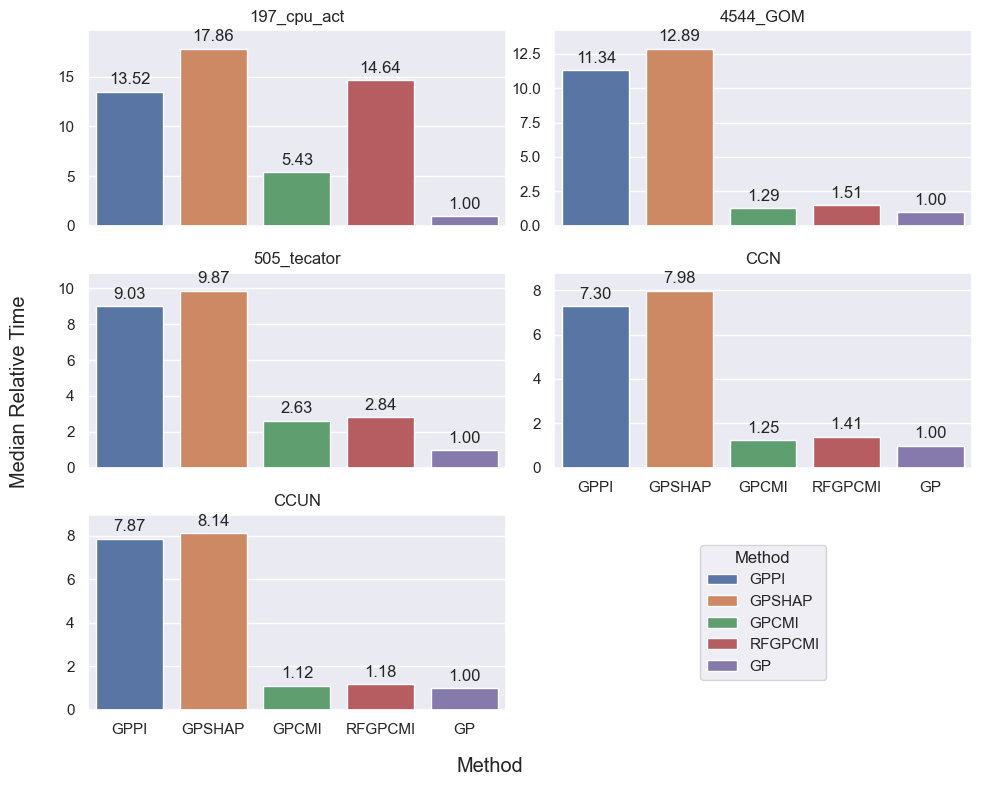

In [17]:
# Plotting relative time of each method compared to GP for each dataset
fig, axes = plot_results(
    relative_time_df, 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level=None, 
    value_key=None,
    plotting_function=lambda data, ax: sns.barplot(data=data, ax=ax),
)

# Set X and Y label for the entire figure
fig.supxlabel("Method", x=0.5, y=0.02)
fig.supylabel("Median Relative Time", x=0.02, y=0.5)

axes[3].tick_params(axis='x', labelbottom=True) # Restore x-tick labels

# Add value labels on top of each bar and adjust y-axis limits for better visibility
for ax in axes[:5]:
    base_padding = 3
    margin_ratio = 0.05

    bottom, top = ax.get_ylim()
    y_padding = margin_ratio * (top - bottom)

    new_top = top + (y_padding if top else 0)
    new_bottom = bottom - (y_padding if bottom else 0)
    ax.set_ylim(new_bottom, new_top)

    for container in ax.containers:
        v = container.datavalues[0]
        adjusted_padding = base_padding if (v != 0) or (top > 0) else -(11 + base_padding)
        ax.bar_label(container, fmt='%.2f', padding=adjusted_padding)

# Take the legend handles and labels from the fifth subplot
handles = axes[4].containers
labels = [text.get_text() for text in axes[4].get_xticklabels()]

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Method"
)
plt.show()

In [18]:
# Calculate relative loss based on the median loss of GP
baseline_loss = median_loss[:, "GP", :]

relative_loss = median_loss / baseline_loss
relative_loss_df = relative_loss.to_frame().T

# Reorder the relative loss DataFrame to match the desired column order for plotting
relative_loss_df = relative_loss_df.reindex(columns=order['dataset'], level='dataset')
relative_loss_df = relative_loss_df.reindex(columns=order['method'], level='method')
relative_loss_df = relative_loss_df.reindex(columns=order['metric'], level='metric')
relative_loss_df

dataset     197_cpu_act                                                \
method             GPPI                                        GPSHAP   
metric  training_losses validation_losses test_losses training_losses   
0              0.771625          0.769207    0.772948        0.768115   

dataset                                                                  \
method                                          GPCMI                     
metric  validation_losses test_losses training_losses validation_losses   
0                0.769431    0.772645         0.99916          1.001253   

dataset                              ...        CCUN                  \
method                      RFGPCMI  ...      GPSHAP           GPCMI   
metric  test_losses training_losses  ... test_losses training_losses   
0          0.999627        0.546279  ...    0.990646        0.989046   

dataset                                                                  \
method                                        RFGPCMI                     
metric  validation_losses test_losses training_losses validation_losses   
0                0.980011    0.992367        0.907155          0.878676   

dataset                                                            
method                           GP                                
metric  test_losses training_losses validation_losses test_losses  
0          0.942512             1.0               1.0         1.0  

[1 rows x 75 columns]

In [19]:
# Calculate computational efficiency as the inverse of the product of relative loss and relative time
computational_efficiency_df = 1 / (relative_loss_df * relative_time_df)

for level, cols in order.items():
    computational_efficiency_df = computational_efficiency_df.reindex(columns=cols, level=level)

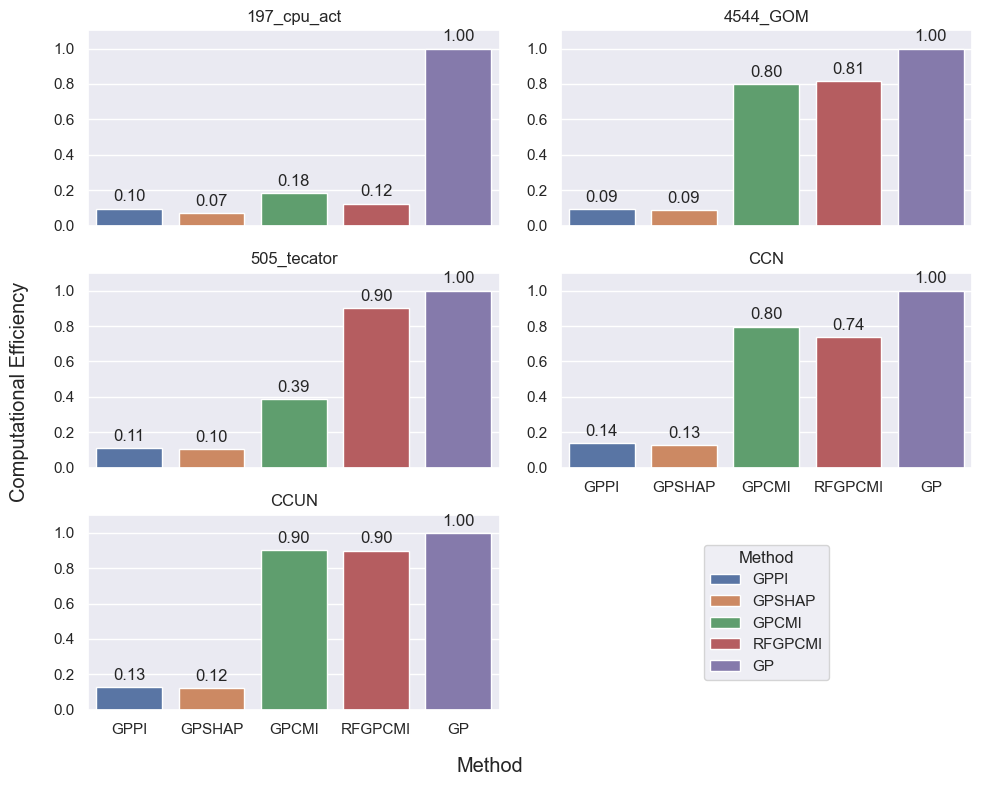

In [20]:
# Plotting the ratio of median test loss to median relative time for each dataset and method
fig, axes = plot_results(
    computational_efficiency_df, 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level="metric", 
    value_key="test_losses",
    plotting_function=lambda data, ax: sns.barplot(data=data, ax=ax),
)

# Set X and Y label for the entire figure
fig.supxlabel("Method", x=0.5, y=0.02)
fig.supylabel("Computational Efficiency", x=0.02, y=0.5)

axes[3].tick_params(axis='x', labelbottom=True) # Restore x-tick labels

# Add value labels on top of each bar and adjust y-axis limits for better visibility
for ax in axes[:5]:
    base_padding = 3
    margin_ratio = 0.05

    bottom, top = ax.get_ylim()
    y_padding = margin_ratio * (top - bottom)

    new_top = top + (y_padding if top else 0)
    new_bottom = bottom - (y_padding if bottom else 0)
    ax.set_ylim(new_bottom, new_top)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=base_padding)

# Take the legend handles and labels from the fifth subplot
handles = axes[4].containers
labels = [text.get_text() for text in axes[4].get_xticklabels()]

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Method"
)
plt.show()

### Bonus

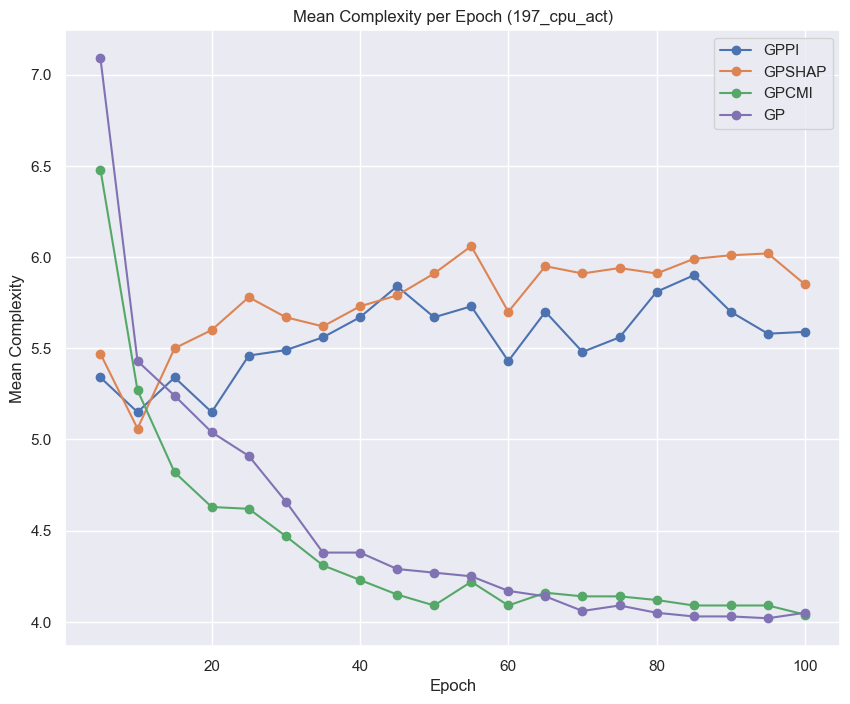

In [21]:
# Mean Complexity Analysis (197_cpu_act)

num_epochs = len(equations['197_cpu_act']['GPPI'][0])
methods_to_plot = [m for m in order['method'] if m != 'RFGPCMI']
method_colors = dict(zip(
    order['method'], 
    sns.color_palette(n_colors=len(order['method']))
))

# Calculate mean complexity for each method
mean_complexities = {}
for m in methods_to_plot:
    mean_complexities[m] = np.empty((num_epochs, num_runs))
    
    for r in range(num_runs):
        for i in range(num_epochs):
            mean_complexities[m][i, r] = equations['197_cpu_act'][m][r][i].complexity
    
    mean_complexities[m] = mean_complexities[m].mean(axis=1)

mean_complexities_df = pd.DataFrame(mean_complexities, index=results_df.index.get_level_values('epoch').unique())
mean_complexities_df = mean_complexities_df[methods_to_plot]

mean_complexities_df.plot(
    figsize=(10, 8), 
    title="Mean Complexity per Epoch (197_cpu_act)", 
    xlabel="Epoch", 
    ylabel="Mean Complexity", 
    marker='o',
    color=method_colors
)
plt.show()

In [22]:
# Print the best final expression for each method on the 197_cpu_act dataset 

dataset_name = '197_cpu_act'

# Print best final expression for each method
for m in order['method']:
    best_run_idx = results_df[dataset_name][m].test_losses.groupby(level='run').last().idxmin()
    
    # Different handling for RFGPCMI since it has multiple sub-expressions
    if m == "RFGPCMI":
        print(f'{m:<7} | {
            sum(
                equations[dataset_name][m][best_run_idx][i][-1].sympy_format
                for i in range(3)
            )
        }')

    else:
        print(f'{m:<7} | {equations[dataset_name][m][best_run_idx][-1].sympy_format}')

    print("-"*20)

GPPI    | freeswap/(0.010456718*freeswap + 7.3099637*vflt)
--------------------
GPSHAP  | (30.267262 - 0.013201188*vflt)*(atan(freeswap - vflt) + 1.5583527)
--------------------
GPCMI   | 2.8240192*freeswap**(1/4) - sqrt(pflt)
--------------------
RFGPCMI | -0.010074394*sread - sqrt(vflt) + 13.816394 + 1/(0.011490004 + 1/freeswap)
--------------------
GP      | 61.467552*atan(sqrt(freeswap)/vflt)
--------------------
